# M5 Forecasting — Notebook 3: XGBoost Quantile Forecasting (GPU)

**Pipeline:** EDA → Feature Engineering → **Forecasting** → Optimization

Trains q10/q50/q90 XGBoost models directly from per-store parquet cache.
- `device="cuda"` uses Kaggle's P100 GPU natively — no special setup needed
- Walk-forward CV streams one fold at a time — peak RAM ~6 GB
- MLflow tracks all runs; SHAP explains the median model

**Prerequisite:** Run `02_feature_engineering.ipynb` first.


In [ ]:
import sys, pathlib, os

# ── Source files path ──────────────────────────────────────────────────────────
# Kaggle  : set to your dataset path
# Local   : set to the project root (folder containing src/)
# Override: export SRC_ROOT=/your/path before running
SRC_ROOT = os.environ.get(
    "SRC_ROOT",
    "/path/to/the/folder/containing/src/and/config.py"
)

if SRC_ROOT not in sys.path:
    sys.path.insert(0, SRC_ROOT)

# ── Load config (handles all other paths automatically) ────────────────────────
from config import print_config, DATA_DIR, CACHE_DIR, OUTPUT_DIR, MODEL_DIR, MLFLOW_URI
print_config()


Environment : kaggle
DATA_DIR    : /kaggle/input/competitions/m5-forecasting-accuracy/
CACHE_DIR   : /kaggle/working/store_cache
OUTPUT_DIR  : /kaggle/working/outputs
MODEL_DIR   : /kaggle/working/models
MLFLOW_URI  : /kaggle/working/mlruns
N_ITEMS     : ALL
N_CV_SPLITS : 3


In [24]:
import gc
import logging
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import shap
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s',
                    datefmt='%H:%M:%S')

from src.data.features import FEATURE_COLS, TARGET_COL, DATE_COL
from src.forecasting.lgbm_quantile import (
    walk_forward_date_splits, wrmsse, dollar_error_cost,
    train_quantile_models, predict_quantiles, load_models,
    compute_shap, _load_slice, QUANTILES, HORIZON,
)
from src.optimization.newsvendor import optimal_order_quantity, CostParams

CACHE_DIR  = CACHE_DIR
MODEL_DIR  = MODEL_DIR
N_CV_SPLITS = 3

COLORS = {'green':'#48bb78','blue':'#63b3ed','orange':'#f6ad55',
          'red':'#fc8181','gray':'#718096','purple':'#b794f4'}
plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a202c',
    'axes.edgecolor':'#2d3748','axes.labelcolor':'#e2e8f0',
    'xtick.color':'#a0aec0','ytick.color':'#a0aec0',
    'text.color':'#e2e8f0','grid.color':'#2d3748',
})

print(f'XGBoost version : {xgb.__version__}')
print(f'Store parquets  : {len(list(__import__("pathlib").Path(CACHE_DIR).glob("*.parquet")))}')
print('Imports OK ✓')


XGBoost version : 3.2.0
Store parquets  : 10
Imports OK ✓


## 1. Verify GPU

In [25]:
# XGBoost with device="cuda" works out of the box on Kaggle GPU sessions
# This cell confirms GPU is available and XGBoost can use it

import subprocess
try:
    gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total',
                                        '--format=csv,noheader']).decode().strip()
    print(f'GPU detected: {gpu_info}')
except Exception:
    print('No GPU detected — training will use CPU (slower)')

# Quick smoke test
test_d = xgb.DMatrix([[1,2],[3,4]], label=[0,1])
xgb.train({"device":"cuda","tree_method":"hist","verbosity":0}, test_d, num_boost_round=1)
print('XGBoost GPU smoke test passed ✓')


GPU detected: Tesla P100-PCIE-16GB, 16384 MiB
XGBoost GPU smoke test passed ✓


## 2. Walk-Forward CV Splits

In [26]:
from pathlib import Path

sample_pq = sorted(Path(CACHE_DIR).glob('features_*.parquet'))[0]
sample_df = pd.read_parquet(sample_pq, columns=[DATE_COL])
all_dates = pd.to_datetime(sample_df[DATE_COL]).sort_values().unique()
del sample_df; gc.collect()

splits = list(walk_forward_date_splits(all_dates, n_splits=N_CV_SPLITS))

print(f'Total dates : {len(all_dates):,}')
print(f'Range       : {all_dates[0].date()} -> {all_dates[-1].date()}')
print()
print(f'{"Fold":<6} {"Train end":>12} {"Val start":>12} {"Val end":>12}')
print('-' * 46)
for i, (tr_end, v_start, v_end) in enumerate(splits):
    print(f'{i:<6} {str(tr_end.date()):>12} {str(v_start.date()):>12} {str(v_end.date()):>12}')


Total dates : 1,885
Range       : 2011-02-26 -> 2016-04-24

Fold      Train end    Val start      Val end
----------------------------------------------
0        2016-01-31   2016-02-01   2016-02-28
1        2016-02-28   2016-02-29   2016-03-27
2        2016-03-27   2016-03-28   2016-04-24


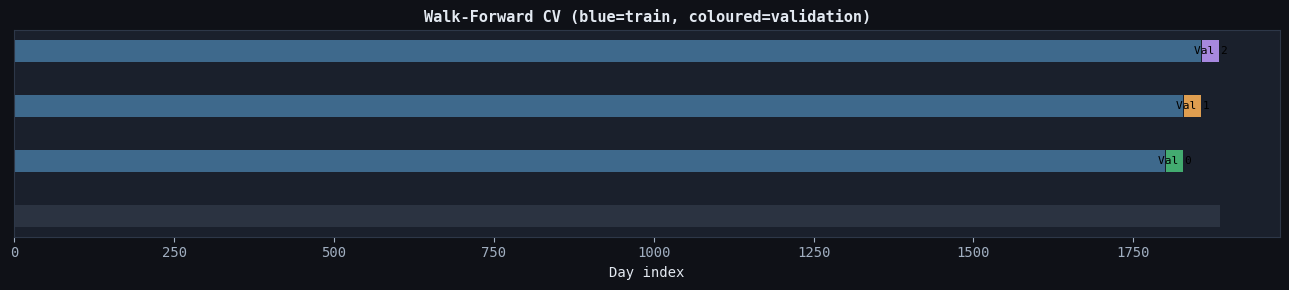

In [40]:
fig, ax = plt.subplots(figsize=(13, 3))
n = len(all_dates)
ax.barh(0, n, color=COLORS['gray'], alpha=0.2, height=0.4)
for i, (tr_end, v_start, v_end) in enumerate(splits):
    tr_pos = np.searchsorted(all_dates, tr_end)
    vs_pos = np.searchsorted(all_dates, v_start)
    ve_pos = np.searchsorted(all_dates, v_end)
    ax.barh(i+1, tr_pos, color=COLORS['blue'], alpha=0.5, height=0.4)
    ax.barh(i+1, ve_pos - vs_pos, left=vs_pos,
            color=[COLORS['green'],COLORS['orange'],COLORS['purple']][i],
            alpha=0.9, height=0.4)
    ax.text(vs_pos + (ve_pos-vs_pos)/2, i+1,
            f'Val {i}', ha='center', va='center', fontsize=8, color='black')
ax.set_title('Walk-Forward CV (blue=train, coloured=validation)')
ax.set_xlabel('Day index'); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 3. Train XGBoost Quantile Models

In [28]:
# Streams from per-store parquets — GPU does the heavy lifting
# Expected: ~10-15 min on P100 for 3 quantiles x 3 folds + final models

os.makedirs(MODEL_DIR, exist_ok=True)
mlflow.set_tracking_uri(MLFLOW_URI)

models = train_quantile_models(
    cache_dir       = CACHE_DIR,
    output_dir      = MODEL_DIR,
    experiment_name = 'm5_xgb_quantile',
    n_cv_splits     = N_CV_SPLITS,
)
print('\nModels trained:', list(models.keys()))


17:07:41 | INFO | Walk-forward splits: 3 folds, horizon=28 days
17:07:41 | INFO |   Fold 0: train <= 2016-01-31 00:00:00 | val 2016-02-01 00:00:00 -> 2016-02-28 00:00:00
17:07:41 | INFO |   Fold 1: train <= 2016-02-28 00:00:00 | val 2016-02-29 00:00:00 -> 2016-03-27 00:00:00
17:07:41 | INFO |   Fold 2: train <= 2016-03-27 00:00:00 | val 2016-03-28 00:00:00 -> 2016-04-24 00:00:00
2026/04/25 17:07:41 INFO mlflow.tracking.fluent: Experiment with name 'm5_xgb_quantile' does not exist. Creating a new experiment.
17:07:41 | INFO | ─── Training q=0.10 ───
17:07:41 | INFO |   Fold 0 — loading train (date <= 2016-01-31 00:00:00)...
17:08:04 | INFO |   Fold 0 — loading val   (2016-02-01 00:00:00 -> 2016-02-28 00:00:00)...
17:08:12 | INFO |   Train: 54,912,490 rows | Val: 853,720 rows


[0]	val-quantile:0.13760
[200]	val-quantile:0.13120
[400]	val-quantile:0.13043
[600]	val-quantile:0.13001
[800]	val-quantile:0.12986
[1000]	val-quantile:0.12972
[1200]	val-quantile:0.12961
[1400]	val-quantile:0.12954
[1600]	val-quantile:0.12946
[1800]	val-quantile:0.12938
[1999]	val-quantile:0.12930


17:21:46 | INFO |   Fold 0 | WRMSSE=0.8095 | $cost=4,413,034
17:21:46 | INFO |   Fold 1 — loading train (date <= 2016-02-28 00:00:00)...
17:22:09 | INFO |   Fold 1 — loading val   (2016-02-29 00:00:00 -> 2016-03-27 00:00:00)...
17:22:17 | INFO |   Train: 55,766,210 rows | Val: 853,720 rows


[0]	val-quantile:0.13764
[200]	val-quantile:0.12995
[400]	val-quantile:0.12921
[600]	val-quantile:0.12882
[800]	val-quantile:0.12862
[1000]	val-quantile:0.12851
[1200]	val-quantile:0.12845
[1400]	val-quantile:0.12843
[1600]	val-quantile:0.12839
[1800]	val-quantile:0.12836
[1999]	val-quantile:0.12832


17:35:43 | INFO |   Fold 1 | WRMSSE=0.7901 | $cost=4,346,212
17:35:44 | INFO |   Fold 2 — loading train (date <= 2016-03-27 00:00:00)...
17:36:06 | INFO |   Fold 2 — loading val   (2016-03-28 00:00:00 -> 2016-04-24 00:00:00)...
17:36:15 | INFO |   Train: 56,619,930 rows | Val: 853,720 rows


...

[0]	val-quantile:0.67846
[200]	val-quantile:0.31719
[400]	val-quantile:0.31602
[600]	val-quantile:0.31562
[800]	val-quantile:0.31532
[1000]	val-quantile:0.31500
[1200]	val-quantile:0.31474
[1400]	val-quantile:0.31455
[1600]	val-quantile:0.31437
[1800]	val-quantile:0.31422
[1999]	val-quantile:0.31408


19:14:25 | INFO |   Fold 1 | WRMSSE=0.8790 | $cost=520,878
19:14:25 | INFO |   Fold 2 — loading train (date <= 2016-03-27 00:00:00)...
19:14:48 | INFO |   Fold 2 — loading val   (2016-03-28 00:00:00 -> 2016-04-24 00:00:00)...
19:14:57 | INFO |   Train: 56,619,930 rows | Val: 853,720 rows


[0]	val-quantile:0.66889
[200]	val-quantile:0.30823
[400]	val-quantile:0.30767
[411]	val-quantile:0.30764


19:17:49 | INFO |   Fold 2 | WRMSSE=0.8735 | $cost=485,183
19:17:49 | INFO |   Training final model on all data...
19:30:19 | INFO |   ✓ q=0.90 | CV WRMSSE=0.8724 ± 0.0060 | CV $cost=513,511



Models trained: [0.1, 0.5, 0.9]


## 4. CV Metrics

In [29]:
results = []
for q, booster in models.items():
    for fold, (tr_end, v_start, v_end) in enumerate(splits):
        X_val, y_val = _load_slice(Path(CACHE_DIR), date_from=v_start, date_to=v_end)
        dval  = xgb.DMatrix(X_val.astype('float32'), feature_names=FEATURE_COLS)
        preds = np.maximum(booster.predict(dval), 0)
        dcost = dollar_error_cost(y_val, preds)
        results.append({
            'quantile'   : q,
            'fold'       : fold,
            'WRMSSE'     : wrmsse(y_val, preds),
            'dollar_cost': dcost['total_cost_usd'],
        })
        del X_val, y_val, preds, dval; gc.collect()

results_df = pd.DataFrame(results)
print(results_df.groupby('quantile')[['WRMSSE','dollar_cost']].mean().round(4))


          WRMSSE   dollar_cost
quantile                      
0.1       0.7928  4.367144e+06
0.5       0.5704  2.441780e+06
0.9       0.8643  5.110516e+05


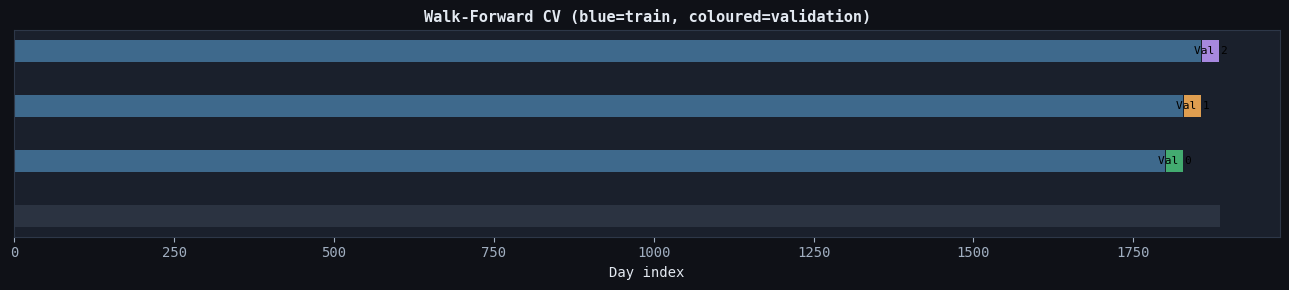

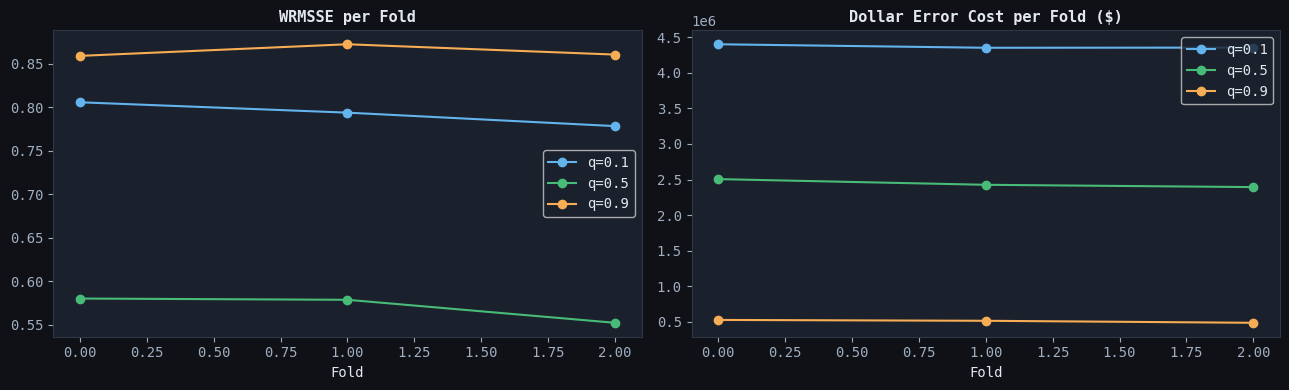

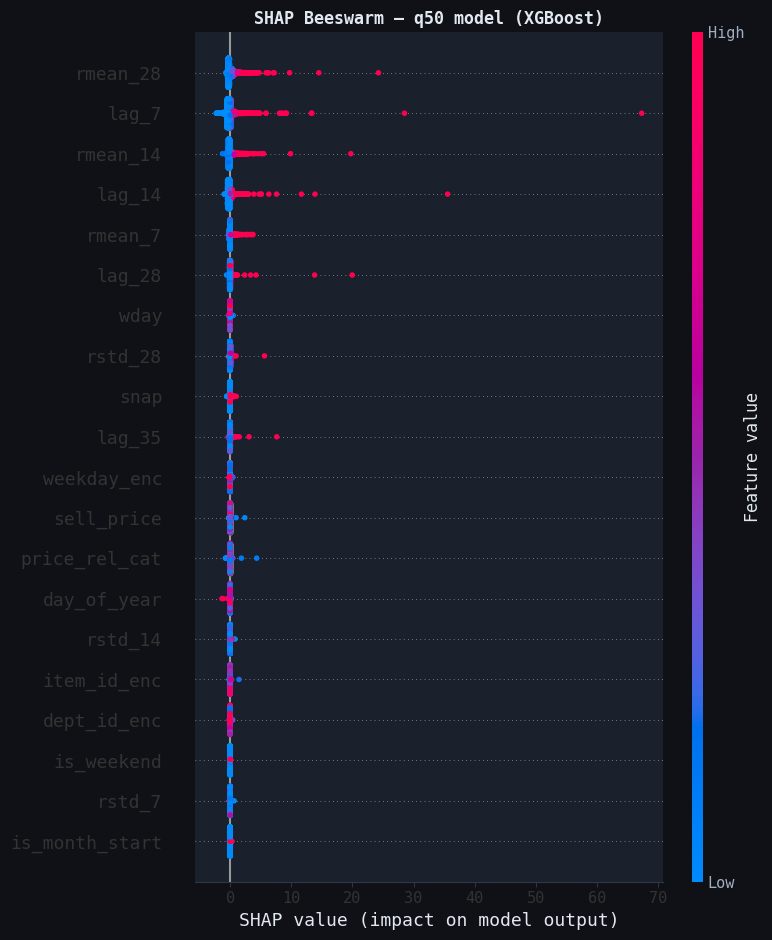

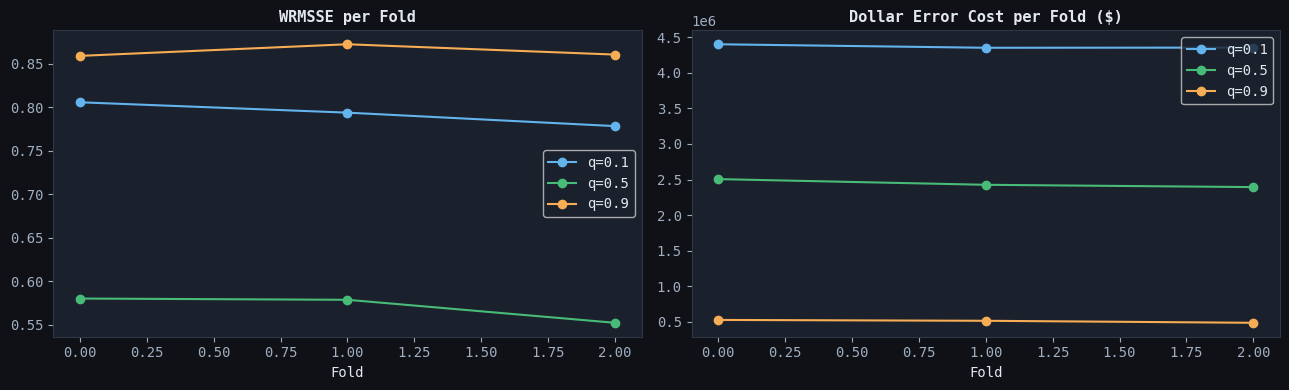

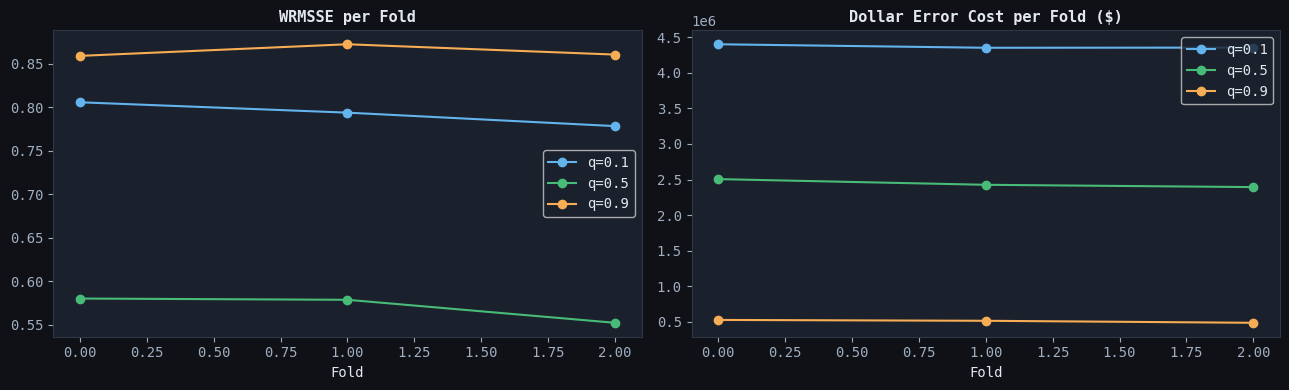

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for q, color in zip(QUANTILES, [COLORS['blue'],COLORS['green'],COLORS['orange']]):
    qdf = results_df[results_df['quantile']==q]
    axes[0].plot(qdf['fold'], qdf['WRMSSE'],      marker='o', color=color, label=f'q={q}')
    axes[1].plot(qdf['fold'], qdf['dollar_cost'], marker='o', color=color, label=f'q={q}')
axes[0].set_title('WRMSSE per Fold'); axes[0].set_xlabel('Fold'); axes[0].legend()
axes[1].set_title('Dollar Error Cost per Fold ($)'); axes[1].set_xlabel('Fold'); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Generate 28-Day Forecasts

In [31]:
last_date = all_dates[-1]
cutoff    = last_date - pd.Timedelta(days=HORIZON - 1)

parts = []
for pq in sorted(Path(CACHE_DIR).glob('features_*.parquet')):
    store = pd.read_parquet(pq)
    store[DATE_COL] = pd.to_datetime(store[DATE_COL])
    chunk = store[store[DATE_COL] >= cutoff].copy()
    if len(chunk):
        parts.append(chunk)
    del store, chunk; gc.collect()

test_df = pd.concat(parts, ignore_index=True)
del parts; gc.collect()

preds_df    = predict_quantiles(models, test_df)
forecast_df = pd.concat([
    test_df[['id','store_id','item_id','date','sales']].reset_index(drop=True),
    preds_df.reset_index(drop=True)
], axis=1)

print(f'Forecast rows : {len(forecast_df):,}')
print(f'Horizon       : {forecast_df["date"].min().date()} -> {forecast_df["date"].max().date()}')
forecast_df.head()


Forecast rows : 853,720
Horizon       : 2016-03-28 -> 2016-04-24


,id,store_id,item_id,date,sales,q10,q50,q90
0,FOODS_1_001_CA_1_validation,CA_1,FOODS_1_001,2016-03-28,2.0,0.0,0.032139,1.914272
1,FOODS_1_001_CA_1_validation,CA_1,FOODS_1_001,2016-03-29,1.0,0.0,0.018352,1.864234
2,FOODS_1_001_CA_1_validation,CA_1,FOODS_1_001,2016-03-30,1.0,0.0,0.019096,1.966167
3,FOODS_1_001_CA_1_validation,CA_1,FOODS_1_001,2016-03-31,0.0,0.0,0.000000,1.811475
4,FOODS_1_001_CA_1_validation,CA_1,FOODS_1_001,2016-04-01,4.0,0.0,0.000000,2.010247


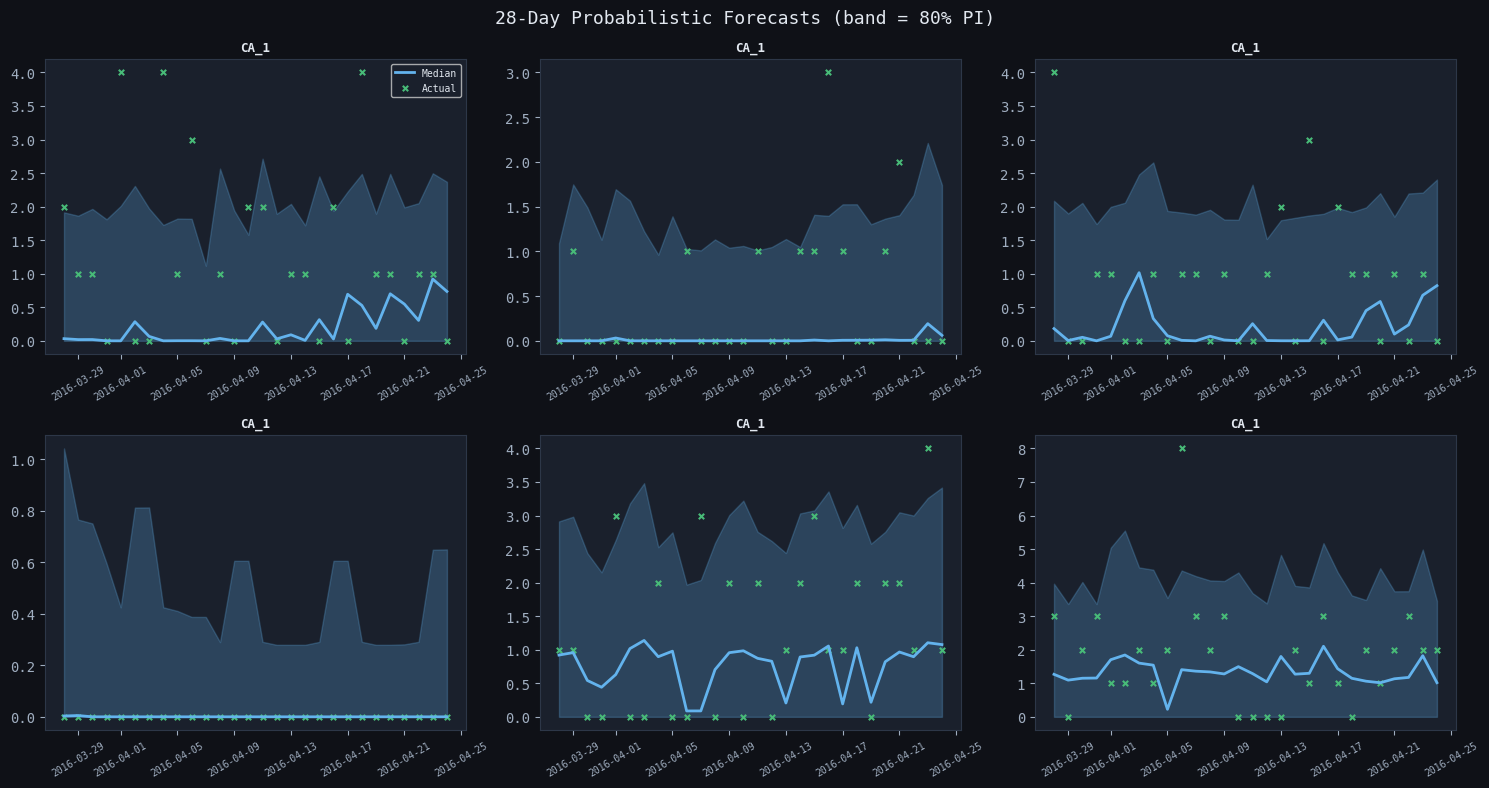

In [41]:
sample_items = forecast_df['id'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('28-Day Probabilistic Forecasts (band = 80% PI)', fontsize=13)
for ax, iid in zip(axes.flatten(), sample_items):
    idf = forecast_df[forecast_df['id']==iid].sort_values('date')
    ax.fill_between(idf['date'], idf['q10'], idf['q90'],
                    alpha=0.25, color=COLORS['blue'])
    ax.plot(idf['date'], idf['q50'], color=COLORS['blue'], lw=2, label='Median')
    ax.scatter(idf['date'], idf['sales'], color=COLORS['green'],
               s=15, marker='x', label='Actual')
    ax.set_title(f'{idf["store_id"].iloc[0]}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
axes[0][0].legend(fontsize=7)
plt.tight_layout()
plt.show()


## 6. SHAP Feature Importance

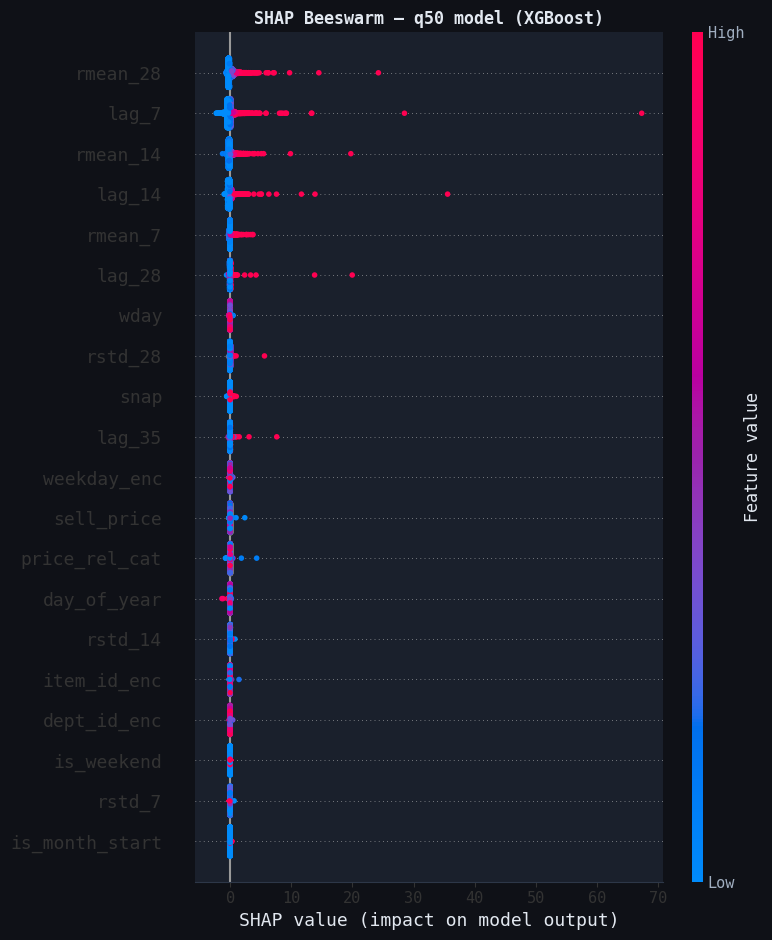

24449

In [42]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

sample_pq   = sorted(Path(CACHE_DIR).glob('features_*.parquet'))[0]
sample_shap = pd.read_parquet(sample_pq).sample(3000, random_state=42)

shap_values = compute_shap(
    models[0.50], sample_shap,
    save_path=Path(f'{OUTPUT_DIR}/shap_beeswarm.png')
)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_shap[FEATURE_COLS],
                  max_display=20, show=False)
plt.title('SHAP Beeswarm — q50 model (XGBoost)', fontsize=12)
plt.tight_layout(); plt.show()
del sample_shap; gc.collect()


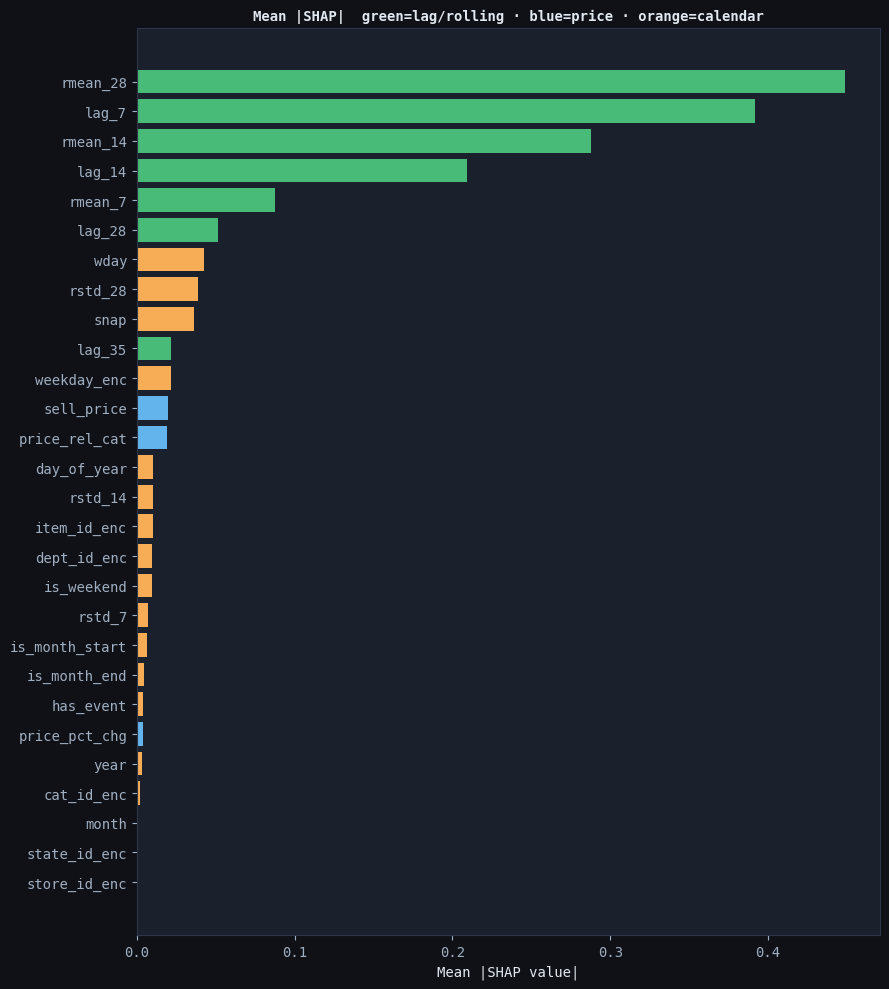

In [43]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                           index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 10))
bar_colors = [COLORS['green'] if 'lag' in f or 'rmean' in f
              else COLORS['blue'] if 'price' in f
              else COLORS['orange'] for f in mean_abs_shap.index]
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=bar_colors, edgecolor='none')
ax.set_title('Mean |SHAP|  green=lag/rolling · blue=price · orange=calendar', fontsize=10)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout(); plt.show()


## 7. Save Forecasts

In [44]:
cost_p = CostParams()
forecast_df['q_star'] = optimal_order_quantity(
    forecast_df['q10'].values,
    forecast_df['q50'].values,
    forecast_df['q90'].values,
    cost=cost_p,
)
rng = np.random.default_rng(42)
forecast_df['inventory'] = np.round(
    forecast_df['q90'].values * rng.uniform(0.8, 1.4, len(forecast_df))
).astype(int)

forecast_df.to_parquet(f'{OUTPUT_DIR}/forecasts.parquet', index=False)
print(f'Saved  -> {OUTPUT_DIR}/forecasts.parquet')
print(f'Columns: {list(forecast_df.columns)}')
print()
print('Next -> 04_optimization.ipynb')


Saved  -> /kaggle/working/outputs/forecasts.parquet
Columns: ['id', 'store_id', 'item_id', 'date', 'sales', 'q10', 'q50', 'q90', 'q_star', 'inventory']

Next -> 04_optimization.ipynb
